In [2]:
# Replace this code if using some other method to load the file

from google.colab import drive
drive.mount('/content/drive')

# Change file path depending on the location of the data
path = "/content/drive/MyDrive/warehouse-bottleneck-analyzer/data/raw/warehouse_line_throughput_synthetic.csv"

Mounted at /content/drive


In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [4]:
# Read the file, ensure "timestamp" is in date-time format
# then set it as the index.

df = pd.read_csv(path)
df["timestamp"] = pd.to_datetime(df["timestamp"])
df = df.sort_values("timestamp").reset_index(drop=True)
df = df.set_index("timestamp")


*There will be analyses on effects of different sets of features, (1) Containing engineered features; (2) containing two sets of features; (3) containing a full feature set.*

In [5]:
# Engineered features
df["capacity_gap"] = (df["available_work"] - df["line_capacity"])
df["work_pressure"] = (df["backlog_units"] / df["planned_work"])
df["backlog_planned_ratio"] = (df["backlog_units"] / df["planned_work"])

# Print a few records and verify values of engineered features
print(df[[
    "available_work",
    "line_capacity",
    "capacity_gap",
    "work_pressure"
]].head())


                     available_work  line_capacity  capacity_gap  \
timestamp                                                          
2026-04-01 00:00:00           893.0            820          73.0   
2026-04-01 01:00:00           840.0            910         -70.0   
2026-04-01 02:00:00           696.0            640          56.0   
2026-04-01 03:00:00           804.0            672         132.0   
2026-04-01 04:00:00           846.0            539         307.0   

                     work_pressure  
timestamp                           
2026-04-01 00:00:00       0.116461  
2026-04-01 01:00:00       0.000000  
2026-04-01 02:00:00       0.030172  
2026-04-01 03:00:00       0.157088  
2026-04-01 04:00:00       0.448133  


In [6]:
# Create sets of features to train and compare models
engineered_features = [
    "backlog_units",
    "available_work",
    "capacity_gap",
    "work_pressure",
    "bottleneck_flag"
]

expanded_features_set_1 = [
    "backlog_units",
    "utilization_rate",
    "packers_assigned",
    "reassigned_packers",
    "work_diverted_out",
    "bottleneck_flag"
]

expanded_features_set_2 = [
    "work_pressure",
    "utilization_rate",
    "packers_assigned",
    "reassigned_packers",
    "work_diverted_out",
    "bottleneck_flag"
]

full_features = [
    "hour",
    "stations_down",
    "active_stations",
    "packers_scheduled",
    "packers_available",
    "packers_available_after_support",
    "added_packers",
    "packers_assigned",
    "reassigned_packers",
    "avg_units_per_packer",
    "planned_work",
    "work_diverted_out",
    "net_incoming_volume",
    "units_packed",
    "available_work",
    "backlog_units",
    "capacity_shortfall",
    "utilization_rate",
    "bottleneck_flag",
    "work_pressure",
    "backlog_planned_ratio",
    "capacity_gap",
    "backlog_lag_1",
    "backlog_lag_2",
    "capacity_gap_lag_1",
    "backlog_change"
]


*Review how many unique values exist for 2 of the expanded sets*

In [7]:
for col in expanded_features_set_1:
    print(col, df[col].nunique())
print()

for col in expanded_features_set_2:
    print(col, df[col].nunique())

backlog_units 1194
utilization_rate 279
packers_assigned 16
reassigned_packers 10
work_diverted_out 206
bottleneck_flag 2

work_pressure 1821
utilization_rate 279
packers_assigned 16
reassigned_packers 10
work_diverted_out 206
bottleneck_flag 2


*At one point I received a singular matrix error when trying to use Logistic Regression. As I created engineered features that were mathematically related, I used Singular Value Decomposition (SVD). SVD is a diagnostic tool that tells you whether your feature set contains redundant information and whether the model will have trouble estimating coefficients reliably, even if the features may have little or moderate correlation. This could lead to large standard errors, sign changes in coefficients, and odds ratios that are difficult to interpret.*
*Additionally, condition numbers generated by SVD will help show how numerically stable the feature set is. Large condition numbers aren't as stable as smaller condition numbers.*

*After viewing the results, and knowing the operational reason behind the features, I concluded a couple of features were not needed. After removing them and running subsequent SVD analyses showed a substantial improvement in numerical stability, by reducing the condition number from approximately 2,041 to 371.*

*SVD is not necessary for other types of analysis tools like Random Forest or XGBoost as they don't estimate coefficients.*

In [8]:
# The Condition number for sets 1 and 3 are extremely high. Efforts should be
# made to find sets with better results, and therefore be more stable.

import statsmodels.api as sm

X = df[expanded_features_set_1]
X_const = sm.add_constant(X)

u, s, vh = np.linalg.svd(X_const)

print("Singular values for feature set 1:")
print(s)

print("\nCondition number for feature set 1:")
print(np.linalg.cond(X_const))
print()

# Removed "reassigned_packers" after SVD results
expanded_features_set_3 = [
    "backlog_units",
    "utilization_rate",
    "packers_assigned",
    "work_diverted_out",
    "bottleneck_flag"
]

X = df[expanded_features_set_3]
X_const = sm.add_constant(X)

u, s, vh = np.linalg.svd(X_const)

print("Singular values for feature set 3:")
print(s)

print("\nCondition number for feature set 3:")
print(np.linalg.cond(X_const))
print()

Singular values for feature set 1:
[2.30046759e+04 2.99513126e+03 4.55356044e+02 6.96540123e+01
 1.97482684e+01 1.15270338e+01 1.68877659e+00]

Condition number for feature set 1:
13622.095441670253

Singular values for feature set 3:
[2.30046758e+04 2.99513126e+03 4.54068449e+02 1.99274170e+01
 1.27388504e+01 1.73409438e+00]

Condition number for feature set 3:
13266.103656532237



*We see that the 4th set of expanded features produced the smallest singular numbers and condition number of all sets, providing strong evidence that the set is the best choice for further analyses.*

In [9]:
X = df[expanded_features_set_2]
X_const = sm.add_constant(X)

u, s, vh = np.linalg.svd(X_const)

print("Singular values for feature set 2:")
print(s)

print("\nCondition number for feature set 2:")
print(np.linalg.cond(X_const))
print()

# Removed "reassigned_packers" and "work_diverted_out" after SVD results

expanded_features_set_4 = [
    "work_pressure",
    "utilization_rate",
    "bottleneck_flag"
]

X = df[expanded_features_set_4]
X_const = sm.add_constant(X)

u, s, vh = np.linalg.svd(X_const)

print("Singular values for feature set 4:")
print(s)

print("\nCondition number for feature set 4:")
print(np.linalg.cond(X_const))
print()

Singular values for feature set 2:
[3.53541129e+03 5.89470686e+02 7.26652944e+01 2.38427287e+01
 1.18540933e+01 9.64803633e+00 1.68071740e+00]

Condition number for feature set 2:
2103.5132377531722

Singular values for feature set 4:
[77.84598875 15.98781915 11.41030737  1.73902262]

Condition number for feature set 4:
44.76421863485205



*Correlation analysis identified moderate relationships between work diverted out, work pressure, and bottleneck conditions. Operational review indicated that work diversion was primarily a management response to workload stress rather than an independent driver of backlog risk. Consequently, the variable was removed from the explanatory feature set.*

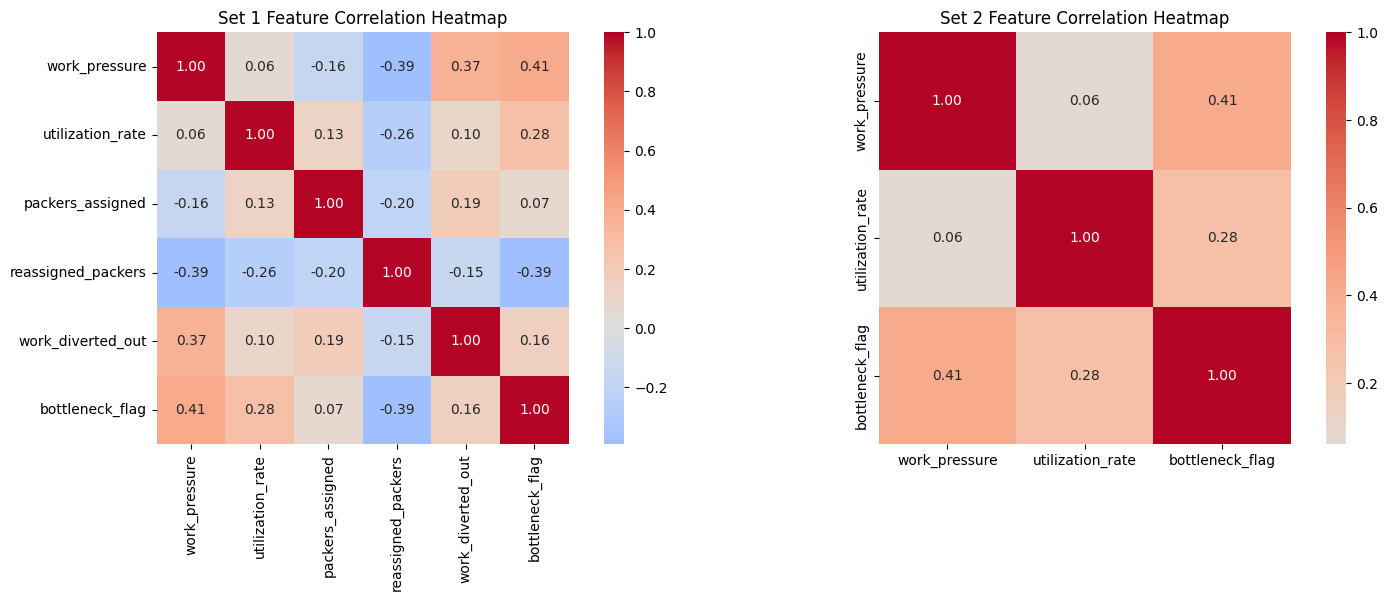

In [10]:
corr1 = (
    df[expanded_features_set_2]
    .corr()
)

corr2 = (
    df[expanded_features_set_4]
    .corr()
)

fig, axes = plt.subplots(
    1,
    2,
    figsize=(16, 6)
)

sns.heatmap(
    corr1,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0,
    square=True,
    ax=axes[0]
)

axes[0].set_title(
    "Set 1 Feature Correlation Heatmap"
)

sns.heatmap(
    corr2,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0,
    square=True,
    ax=axes[1]
)

axes[1].set_title(
    "Set 2 Feature Correlation Heatmap"
)

plt.tight_layout()
plt.show()


*Time to check engineered features. As a couple were calculated with some of the same features, I check correlation and ensure I'm not adding variables that measure the same thing multiple times. Standard errors could be inflated and expanded models could struggle to answer which variables(s) are actually driving risk, and worse the models became statistically unreliable. I check if I get singular matrix errors, or max iteration timeouts, when fitting*

In [11]:
# We see the 3rd set of engineered features produce the smallest
# singular values and condition number.

X = df[engineered_features]
X_const = sm.add_constant(X)

u, s, vh = np.linalg.svd(X_const)

print("Singular values for engineered feature set:")
print(s)

print("\nCondition number for engineered feature set:")
print(np.linalg.cond(X_const))
print()

engineered_features_2 = [
    "available_work",
    "work_pressure",
    "bottleneck_flag"
]

X = df[engineered_features_2]
X = sm.add_constant(X)

print(np.linalg.cond(X))
print()

engineered_features_3 = [
    "work_pressure",
    "bottleneck_flag"
]

X = df[engineered_features_3]
X = sm.add_constant(X)

print(np.linalg.cond(X))


Singular values for engineered feature set:
[7.68958965e+04 1.62927962e+04 1.96587288e+03 1.84324889e+01
 9.95582081e+00 4.35983341e+00]

Condition number for engineered feature set:
17637.34742833954

7291.919719529131

5.587155952497129


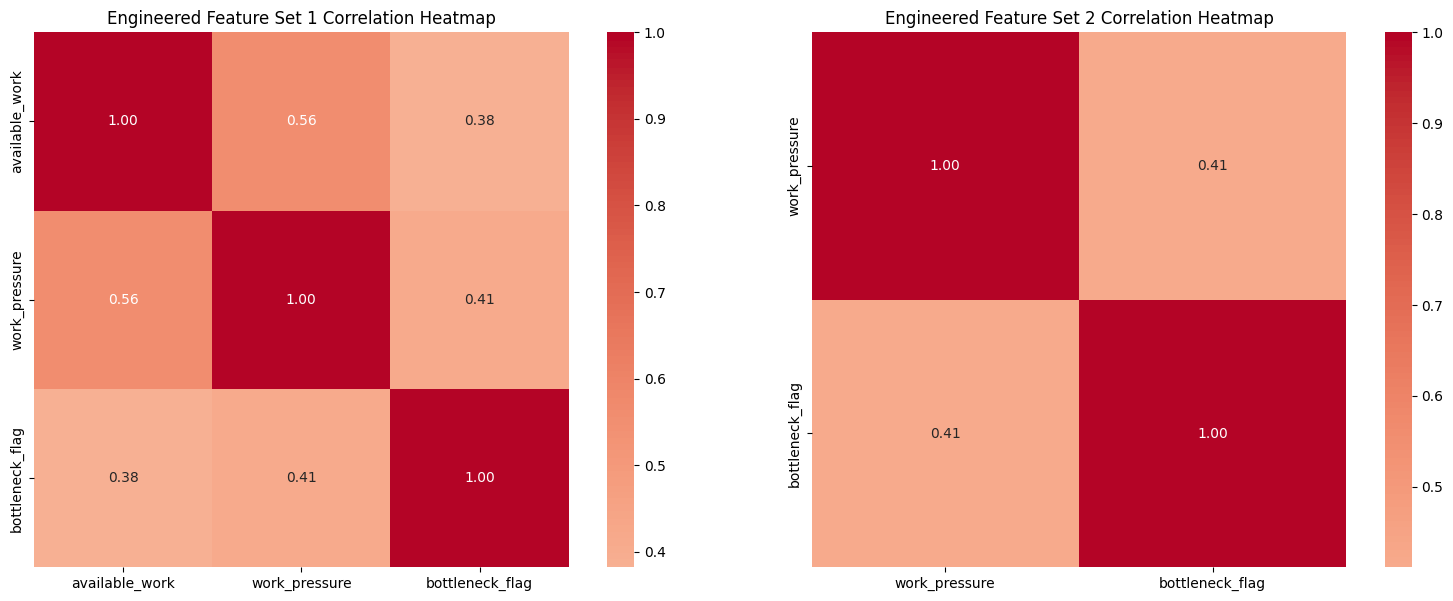

In [12]:
corr_eng_1 = (
    df[engineered_features_2]
    .corr()
)

corr_eng_2 = (
    df[engineered_features_3]
    .corr()
)

fig, axes = plt.subplots(
    1,
    2,
    figsize=(16, 6)
)

sns.heatmap(
    corr_eng_1,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0,
    square=True,
    ax=axes[0]
)

axes[0].set_title(
    "Engineered Feature Set 1 Correlation Heatmap"
)

sns.heatmap(
    corr_eng_2,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0,
    square=True,
    ax=axes[1]
)

axes[1].set_title(
    "Engineered Feature Set 2 Correlation Heatmap"
)

plt.tight_layout()
plt.show()


plt.show()


*Having determined models look stable, I'm going to compare three different models and see which perform best. Strong tests include Log-Likelihood, AIC, BIC, and Pseudo_R2. Models could be stronger for some values, while weaker for others values, which requires determining how well they fit the business goal. I also try to prioritize values if possible, like BIC values have more emphasis, then AIC, log-likelihood, and finally Pseudo R-squared.*  

In [13]:
y = df["next_hour_backlog_risk"]

In [14]:
X_engineered_1 = df[engineered_features_2]
X_engineered_1 = sm.add_constant(X_engineered_1)

sm_model_engineered_1 = sm.Logit(y, X_engineered_1).fit()
print(sm_model_engineered_1.summary())
print()

X_engineered_2 = df[engineered_features_3]
X_engineered_2 = sm.add_constant(X_engineered_2)

sm_model_engineered_2 = sm.Logit(y, X_engineered_2).fit()
print(sm_model_engineered_2.summary())

Optimization terminated successfully.
         Current function value: 0.312257
         Iterations 8
                             Logit Regression Results                             
Dep. Variable:     next_hour_backlog_risk   No. Observations:                 2159
Model:                              Logit   Df Residuals:                     2155
Method:                               MLE   Df Model:                            3
Date:                    Wed, 24 Jun 2026   Pseudo R-squ.:                  0.3172
Time:                            12:26:03   Log-Likelihood:                -674.16
converged:                           True   LL-Null:                       -987.38
Covariance Type:                nonrobust   LLR p-value:                1.880e-135
                      coef    std err          z      P>|z|      [0.025      0.975]
-----------------------------------------------------------------------------------
const              -6.3818      0.500    -12.773      0.000      -

In [15]:
X_expanded = df[expanded_features_set_4]
X_expanded = sm.add_constant(X_expanded)

sm_model_expanded = sm.Logit(y, X_expanded).fit()

print(sm_model_expanded.summary())


Optimization terminated successfully.
         Current function value: 0.334414
         Iterations 8
                             Logit Regression Results                             
Dep. Variable:     next_hour_backlog_risk   No. Observations:                 2159
Model:                              Logit   Df Residuals:                     2155
Method:                               MLE   Df Model:                            3
Date:                    Wed, 24 Jun 2026   Pseudo R-squ.:                  0.2688
Time:                            12:26:03   Log-Likelihood:                -722.00
converged:                           True   LL-Null:                       -987.38
Covariance Type:                nonrobust   LLR p-value:                1.033e-114
                       coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------------
const               -3.0164      1.356     -2.224      0.026    

In [16]:
# The set with available work, work pressure, and bottleneck flag produced the
# smallest BIC and AIC numbers, and the number closest to 0. At the same time,
# the Pseudo R-squared value explains more of the variation than the other
# models.

comparison_df = pd.DataFrame({
    "Model": [
        "Work Pressure + Bottleneck",
        "Available Work + Work Pressure + Bottleneck",
        "Available Work + Work Pressure + Bottleneck + Utilization"
    ],
    "Log-Likelihood": [
        sm_model_engineered_2.llf,
        sm_model_engineered_1.llf,
        sm_model_expanded.llf
    ],
    "AIC": [
        sm_model_engineered_2.aic,
        sm_model_engineered_1.aic,
        sm_model_expanded.aic
    ],
    "BIC": [
        sm_model_engineered_2.bic,
        sm_model_engineered_1.bic,
        sm_model_expanded.bic
    ],
    "Pseudo_R2": [
        sm_model_engineered_2.prsquared,
        sm_model_engineered_1.prsquared,
        sm_model_expanded.prsquared
    ]
}).round(4)

print(
    comparison_df.to_string(index=False)
)

                                                    Model  Log-Likelihood       AIC       BIC  Pseudo_R2
                               Work Pressure + Bottleneck       -722.7097 1451.4194 1468.4516     0.2680
              Available Work + Work Pressure + Bottleneck       -674.1620 1356.3241 1379.0337     0.3172
Available Work + Work Pressure + Bottleneck + Utilization       -722.0005 1452.0010 1474.7106     0.2688


*Odds ratios are reviewed to understand whether each variable increases
or decreases estimated backlog risk, and whether those effects remain
stable as other related variables are added. In this particular analysis, risk was not decreased adding variables and the effects remained stable.*

*I expected adding variables would either add more explanation or the opposite; extremely little. If they reduced risk, I check the model summary for the coefficients, standard error, and p-values. I also check the correlations of the variables because maybe the new model is struggling to separate the effects. Checking the condition values may yield an increase, pointing to instability.*

In [17]:
# The models appear operationally stable because the major drivers retain
# their direction and relative importance across specifications. The odds
# ratios do not show evidence of coefficient sign reversals or dramatic swings
# that would suggest severe multicollinearity or unstable estimation.
# It affirms what was found in condition-number analysis and model-comparison.

odds_ratios_eng_1 = pd.DataFrame({
    "feature": X_engineered_1.columns,
    "odds_ratio": np.exp(sm_model_engineered_1.params)
})

print(odds_ratios_eng_1,"\n")

odds_ratios_eng_2 = pd.DataFrame({
    "feature": X_engineered_2.columns,
    "odds_ratio": np.exp(sm_model_engineered_2.params)
})

print(odds_ratios_eng_2,"\n")

odds_ratios_ex = pd.DataFrame({
    "feature": X_expanded.columns,
    "odds_ratio": np.exp(sm_model_expanded.params)
})

print(odds_ratios_ex,"\n")


                         feature  odds_ratio
const                      const    0.001692
available_work    available_work    1.001648
work_pressure      work_pressure   41.221247
bottleneck_flag  bottleneck_flag    1.742411 

                         feature  odds_ratio
const                      const    0.010636
work_pressure      work_pressure   88.406904
bottleneck_flag  bottleneck_flag    3.313812 

                           feature  odds_ratio
const                        const    0.048979
work_pressure        work_pressure   86.362854
utilization_rate  utilization_rate    0.198349
bottleneck_flag    bottleneck_flag    3.632662 



*Now we'll look at adding a model with an interaction term of work pressure and packers assigned. The question will arise is if the model with the interaction term has better AIC, BIC, etc. values, is there a large enough difference between it and one without an interaction term to warrant the extra complexity.*

In [18]:
import statsmodels.formula.api as smf

smf_model = smf.logit(
    formula="""
    next_hour_backlog_risk ~
    work_pressure +
    packers_assigned +
    work_pressure:packers_assigned
    """,
    data=df
).fit()

print(smf_model.summary())

Optimization terminated successfully.
         Current function value: 0.319925
         Iterations 7
                             Logit Regression Results                             
Dep. Variable:     next_hour_backlog_risk   No. Observations:                 2159
Model:                              Logit   Df Residuals:                     2155
Method:                               MLE   Df Model:                            3
Date:                    Wed, 24 Jun 2026   Pseudo R-squ.:                  0.3005
Time:                            12:26:03   Log-Likelihood:                -690.72
converged:                           True   LL-Null:                       -987.38
Covariance Type:                nonrobust   LLR p-value:                2.834e-128
                                     coef    std err          z      P>|z|      [0.025      0.975]
--------------------------------------------------------------------------------------------------
Intercept                         -4

In [19]:
# The interaction model says that work pressure alone does not fully explain
# backlog risk; the impact of work pressure depends on staffing levels.
# High work pressure is most dangerous when staffing is insufficient, which
# makes sense operationally.

model_1 = smf.logit(
    "next_hour_backlog_risk ~ work_pressure",
    data=df
).fit()

model_2 = smf.logit(
    "next_hour_backlog_risk ~ work_pressure + work_pressure * packers_assigned",
    data=df
).fit()

print(model_1.summary())
print()
print(model_2.summary())

Optimization terminated successfully.
         Current function value: 0.336829
         Iterations 7
Optimization terminated successfully.
         Current function value: 0.319925
         Iterations 7
                             Logit Regression Results                             
Dep. Variable:     next_hour_backlog_risk   No. Observations:                 2159
Model:                              Logit   Df Residuals:                     2157
Method:                               MLE   Df Model:                            1
Date:                    Wed, 24 Jun 2026   Pseudo R-squ.:                  0.2635
Time:                            12:26:03   Log-Likelihood:                -727.21
converged:                           True   LL-Null:                       -987.38
Covariance Type:                nonrobust   LLR p-value:                3.598e-115
                    coef    std err          z      P>|z|      [0.025      0.975]
--------------------------------------------------

In [20]:
comparison_df = pd.DataFrame({
    "Model": [
        "Work Pressure Only",
        "Interaction Model"
    ],
    "Pseudo R2": [
        model_1.prsquared,
        model_2.prsquared
    ],
    "Log-Likelihood": [
        model_1.llf,
        model_2.llf
    ],
    "AIC": [
        model_1.aic,
        model_2.aic
    ],
    "BIC": [
        model_1.bic,
        model_2.bic
    ]
})

comparison_df

,Model,Pseudo R2,Log-Likelihood,AIC,BIC
0,Work Pressure Only,0.263488,-727.213745,1458.427489,1469.782290
1,Interaction Model,0.300451,-690.717568,1389.435135,1412.144737


In [21]:
np.exp(model_2.params)

,0
Intercept,0.013264
work_pressure,10.078481
packers_assigned,1.028660
work_pressure:packers_assigned,1.296551


*Looking at predicted backlog as a function of work pressure with the interaction of packer assigned, it would look like higher staffing increases risk, but that's not the case. From an operations perspective, management would increase staffing when there is a risk of backlog. In other words it's a reactive feature instead of a predictor feature.*

*Looking at operations metrics by staffing, staffing levels increase as workload volume increases, substantially expanding line capacity. However, the highest staffing conditions still exhibit the greatest backlog risk because incoming workload grows faster than capacity. This suggests staffing helps mitigate congestion but may be insufficient by itself under extreme demand conditions.*

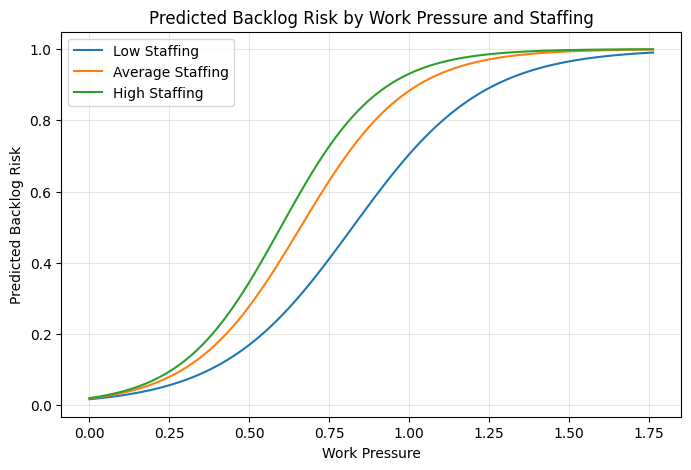

In [22]:
# Representative staffing levels
low_staff = (
    df["packers_assigned"]
    .quantile(0.25)
)

avg_staff = (
    df["packers_assigned"]
    .median()
)

high_staff = (
    df["packers_assigned"]
    .quantile(0.75)
)

# Range of work pressure values
pressure_range = np.linspace(
    df["work_pressure"].min(),
    df["work_pressure"].max(),
    100
)

plt.figure(figsize=(8, 5))

for staff, label in [
    (low_staff, "Low Staffing"),
    (avg_staff, "Average Staffing"),
    (high_staff, "High Staffing")
]:

    pred_df = pd.DataFrame(
        {
        "work_pressure": pressure_range,
        "packers_assigned": staff}
        )

    pred_df["work_pressure:packers_assigned"] = (
        pred_df["work_pressure"] * pred_df["packers_assigned"]
    )

    backlog_risk = (model_2.predict(pred_df))

    plt.plot(
        pressure_range,
        backlog_risk,
        label=label
    )

plt.xlabel("Work Pressure")

plt.ylabel("Predicted Backlog Risk")

plt.title("Predicted Backlog Risk by Work Pressure and Staffing")

plt.legend()

plt.grid(
    alpha=0.3
)

plt.show()

In [23]:
df["staffing_bucket"] = pd.qcut(
    df["packers_assigned"],
    q=3,
    labels=[
        "Low",
        "Medium",
        "High"
    ]
)

print(
    df.groupby(
        "staffing_bucket", observed=False)
    ["next_hour_backlog_risk"].mean()
)

print("\n",
      df.groupby("staffing_bucket", observed=False)
      ["work_pressure"].mean()
)

print("\n",
      df.groupby("staffing_bucket", observed=False)
      [
          [
              "available_work",
              "backlog_units",
              "capacity_gap",
              "line_capacity"
              ]
          ].mean()
          )

staffing_bucket
Low       0.159367
Medium    0.175190
High      0.184211
Name: next_hour_backlog_risk, dtype: float64

 staffing_bucket
Low       0.371023
Medium    0.257422
High      0.282557
Name: work_pressure, dtype: float64

                  available_work  backlog_units  capacity_gap  line_capacity
staffing_bucket                                                            
Low                 1105.512165     334.137470    313.939173     791.572993
Medium              1577.328074     349.266866    331.658868    1245.669206
High                1926.347488     412.667464    408.873804    1517.473684


*The next analyses use Decision Tree and Random Forest models, attempting to answer the question "What operational rules separate low-risk from high-risk situations?"*

*The Decision Tree was used primarily for operational rule discovery. Its goal was not only prediction, but to identify interpretable thresholds where backlog risk changes, such as specific levels of work pressure or utilization.*

*The Random Forest is as a more robust tree-based model. Because Random Forests aggregate many decision trees, they are less sensitive to individual split decisions and can better capture nonlinear relationships and interactions among operational variables. Feature importance and permutation importance were then compared to determine which variables the model used most and which variables most affected predictive performance.*

In [24]:
# Decision Tree for Operational Rule Discovery

from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier, plot_tree, export_text
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

# Target will be the hourly backlog risk

target_col = "next_hour_backlog_risk"

# The first run included backlog units and capacity gap, but subsequent runs
# removed the features as they seemed to provide the same information
# as a couple of engineered columns

feature_cols = [
    "work_pressure",
    "packers_assigned",
    "stations_down",
    "utilization_rate",
    "bottleneck_flag",
    "work_diverted_out"
]

X = df[feature_cols]
y = df[target_col]

In [25]:
# Train/test split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.30,
    random_state=222,
    stratify=y
)

In [26]:
# Shallow decision tree for interpretability

tree_model = DecisionTreeClassifier(
    max_depth=3,
    min_samples_leaf=25,
    random_state=112233,
    class_weight="balanced"
)

tree_model.fit(X_train, y_train)

DecisionTreeClassifier(class_weight='balanced', max_depth=3,
                       min_samples_leaf=25, random_state=112233)

In [27]:
# Predictions and evaluation

y_pred = tree_model.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred))

print("\nClassification Report:")
print(classification_report(y_test, y_pred))

Accuracy: 0.7083333333333334

Confusion Matrix:
[[360 177]
 [ 12  99]]

Classification Report:
              precision    recall  f1-score   support

           0       0.97      0.67      0.79       537
           1       0.36      0.89      0.51       111

    accuracy                           0.71       648
   macro avg       0.66      0.78      0.65       648
weighted avg       0.86      0.71      0.74       648



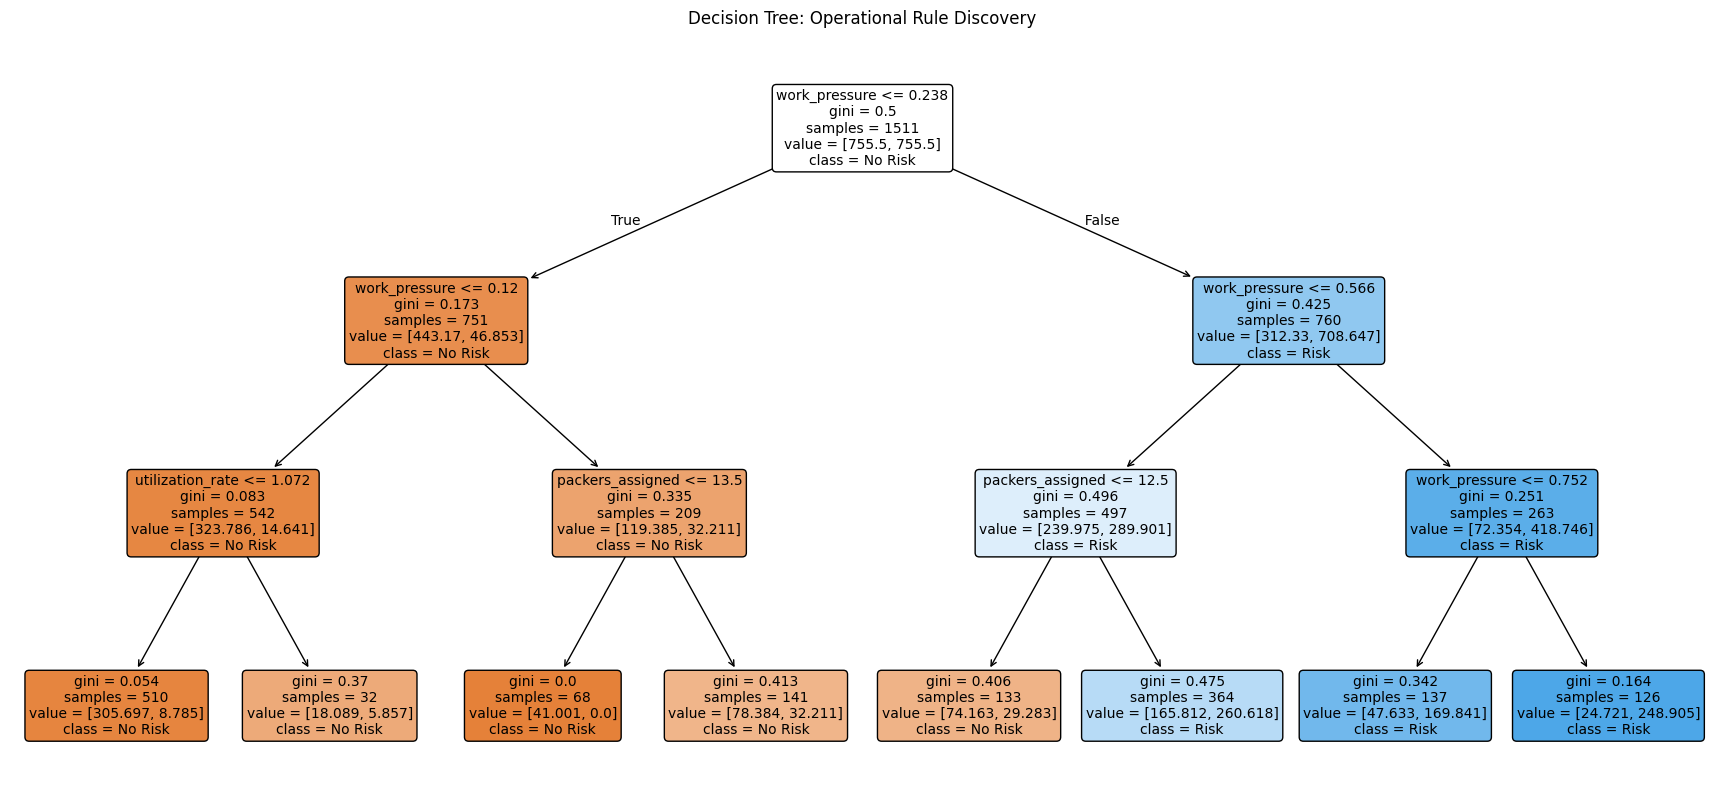

In [28]:
# Visualize the tree

plt.figure(figsize=(22, 10))

plot_tree(
    tree_model,
    feature_names=feature_cols,
    class_names=["No Risk", "Risk"],
    filled=True,
    rounded=True,
    fontsize=10
)

plt.title("Decision Tree: Operational Rule Discovery")
plt.show()

In [29]:
# Look at the first split
print("Root split feature:")
print(feature_cols[tree_model.tree_.feature[0]])

print("Root split threshold:")
print(tree_model.tree_.threshold[0])

Root split feature:
work_pressure
Root split threshold:
0.23770812898874283


In [30]:
rules = export_text(
    tree_model,
    feature_names=feature_cols
)

print(rules)

|--- work_pressure <= 0.24
|   |--- work_pressure <= 0.12
|   |   |--- utilization_rate <= 1.07
|   |   |   |--- class: 0
|   |   |--- utilization_rate >  1.07
|   |   |   |--- class: 0
|   |--- work_pressure >  0.12
|   |   |--- packers_assigned <= 13.50
|   |   |   |--- class: 0
|   |   |--- packers_assigned >  13.50
|   |   |   |--- class: 0
|--- work_pressure >  0.24
|   |--- work_pressure <= 0.57
|   |   |--- packers_assigned <= 12.50
|   |   |   |--- class: 0
|   |   |--- packers_assigned >  12.50
|   |   |   |--- class: 1
|   |--- work_pressure >  0.57
|   |   |--- work_pressure <= 0.75
|   |   |   |--- class: 1
|   |   |--- work_pressure >  0.75
|   |   |   |--- class: 1



*The one tree shows work_pressure has the greatest importance, and the largest split, but it won't go into too much depth.*

In [31]:
# Feature importance table

importance_df = pd.DataFrame({
    "Feature": feature_cols,
    "Importance": tree_model.feature_importances_
}).sort_values(by="Importance", ascending=False)

importance_df

,Feature,Importance
0,work_pressure,0.921575
1,packers_assigned,0.071895
3,utilization_rate,0.006530
2,stations_down,0.000000
4,bottleneck_flag,0.000000
5,work_diverted_out,0.000000


*Naturally, as the gap increases between available work and throughput, work pressure increases.*

               capacity_gap  work_pressure
capacity_gap       1.000000       0.907034
work_pressure      0.907034       1.000000


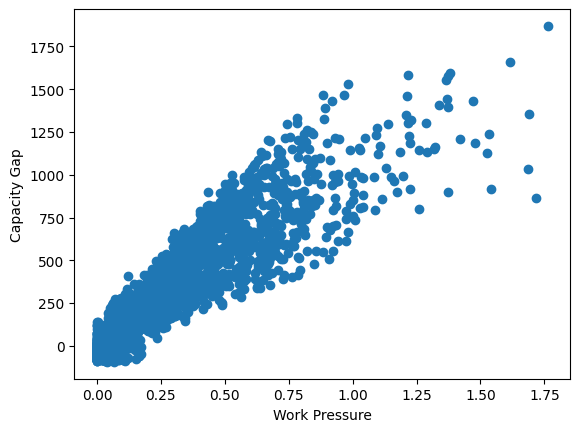

In [32]:
print(df[["capacity_gap", "work_pressure"]].corr())

plt.scatter(
    df["work_pressure"],
    df["capacity_gap"]
)

plt.xlabel("Work Pressure")
plt.ylabel("Capacity Gap")
plt.show()

*Model using Random Forest, which uses a lot of trees*

In [33]:
from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(
    n_estimators=300,
    max_depth=5,
    min_samples_leaf=20,
    random_state=789,
    class_weight="balanced"
)

rf_model.fit(X_train, y_train)

RandomForestClassifier(class_weight='balanced', max_depth=5,
                       min_samples_leaf=20, n_estimators=300, random_state=789)

In [34]:
y_pred = rf_model.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred))

print("\nClassification Report:")
print(classification_report(y_test, y_pred))

Accuracy: 0.7577160493827161

Confusion Matrix:
[[395 142]
 [ 15  96]]

Classification Report:
              precision    recall  f1-score   support

           0       0.96      0.74      0.83       537
           1       0.40      0.86      0.55       111

    accuracy                           0.76       648
   macro avg       0.68      0.80      0.69       648
weighted avg       0.87      0.76      0.79       648



*With many trees available, several features get a chance to
contribute more.*

In [35]:
importance_df = pd.DataFrame({
    "Feature": feature_cols,
    "Importance": rf_model.feature_importances_
}).sort_values(
    by="Importance",
    ascending=False
)

importance_df

,Feature,Importance
0,work_pressure,0.638561
5,work_diverted_out,0.137814
4,bottleneck_flag,0.096101
3,utilization_rate,0.063383
1,packers_assigned,0.049426
2,stations_down,0.014715


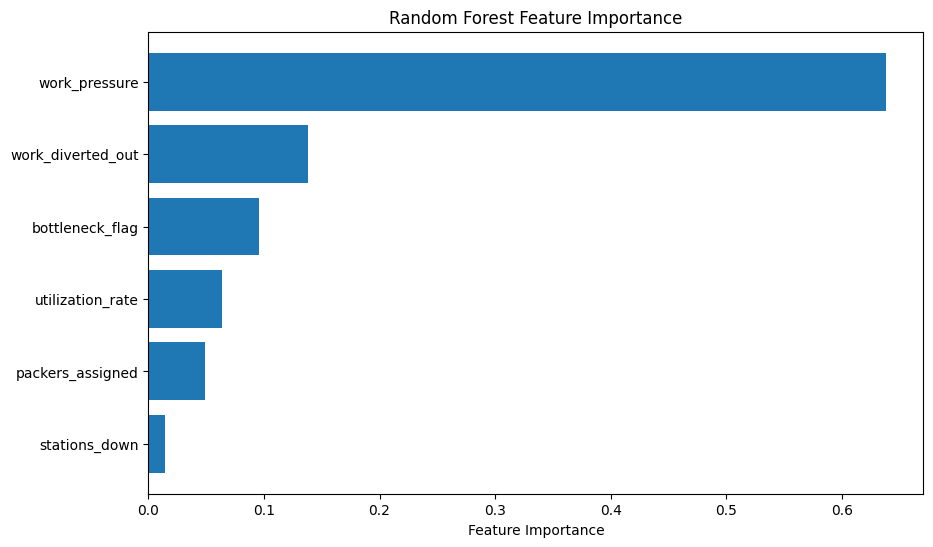

In [36]:
plt.figure(figsize=(10, 6))

plt.barh(
    importance_df["Feature"],
    importance_df["Importance"]
)

plt.gca().invert_yaxis()
plt.xlabel("Feature Importance")
plt.title("Random Forest Feature Importance")
plt.show()

*Permutation shows that work_pressure will negatively affect the model the most if removed, and less so with the other features.*

In [37]:
from sklearn.inspection import permutation_importance

perm_result = permutation_importance(
    rf_model,
    X_test,
    y_test,
    n_repeats=20,
    random_state=56,
    scoring="f1"
)

perm_df = pd.DataFrame({
    "Feature": feature_cols,
    "Permutation Importance": perm_result.importances_mean,
    "Std": perm_result.importances_std
}).sort_values(
    by="Permutation Importance",
    ascending=False
)

perm_df

,Feature,Permutation Importance,Std
0,work_pressure,0.283981,0.035141
1,packers_assigned,0.033032,0.014475
3,utilization_rate,0.019294,0.008986
2,stations_down,0.007719,0.004239
4,bottleneck_flag,0.006081,0.014542
5,work_diverted_out,0.001199,0.004530


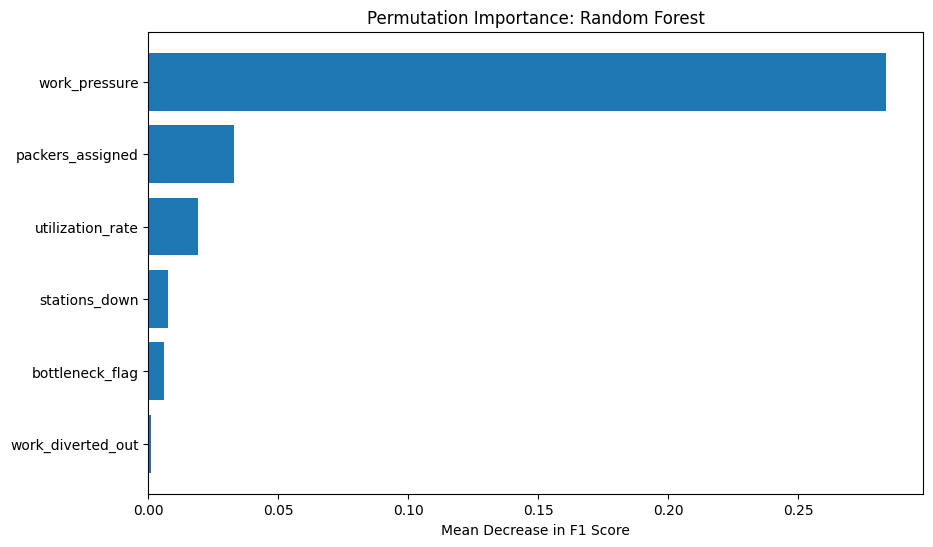

In [38]:
plt.figure(figsize=(10, 6))

plt.barh(
    perm_df["Feature"],
    perm_df["Permutation Importance"]
)

plt.gca().invert_yaxis()
plt.xlabel("Mean Decrease in F1 Score")
plt.title("Permutation Importance: Random Forest")
plt.show()

*The tree-based models reinforced the earlier statistical findings that workload pressure was the dominant operational signal associated with next-hour backlog risk. Decision Tree rules provided threshold-based evidence that backlog risk did not increase uniformly across all conditions, but instead appeared to shift as pressure periods increased.*

*Random Forest feature importance showed that workload pressure carried the largest share of explanatory value, while secondary variables contributed smaller amounts of information. This suggests most of the model's explanatory power is concentrated in workload pressure.*

*A key interpretation is that staffing and diverted work reflect responses to stress rather than independent causes of risk (which makes sense). For example, additional packers added during high-pressure periods are a response to increased pressure. Therefore, tree-based results were interpreted of operational state patterns instead of causal effects.*

In [39]:
# Uncomment if SHAP needs to be installed
#!pip install shap

In [40]:
import shap
print(shap.__version__)

0.52.0


*SHAP takes the Random Forest model to 'explain' the effect of each feature column on the target 'next hour backlog risk'*

In [41]:
# The observations will be resource-intensive, so choosing an arbitrary
# yet reasonable subset of roughly 1500 records. Update sample size if changes
# are made to the training dataset
X_sample = X_train.sample(
    n=500,
    random_state=111
)

# Forcing the TreeExplainer to use the number of samples selected
# SHAP will default to 100 without using a mask. Note that this decision
# was based on SHAP version 0.52.0; this behavior could possibly change
# in future versions.
mask_for_data_subset = shap.maskers.Independent(
    X_sample,
    max_samples=X_sample.shape[0]
)

# Create SHAP explainer for the Random Forest
explainer = shap.Explainer(
    rf_model,
    mask_for_data_subset,
    algorithm="tree",
    model_output="probability"
)

# Calculate SHAP values on the test set
shap_values = explainer.shap_values(X_test)

print("\nExplainer expected value:", explainer.expected_value)
print("Train mean predicted probability:", rf_model.predict_proba(X_train)[:, 1].mean())
print("Test mean predicted probability:", rf_model.predict_proba(X_test)[:, 1].mean())

 99%|===================| 1287/1296 [01:27<00:00]       


Explainer expected value: [0.62660579 0.37339421]
Train mean predicted probability: 0.3657842680496502
Test mean predicted probability: 0.36856999774548366


In [42]:
# Get SHAP values for class 1: next_hour_backlog_risk = 1

# Older SHAP versions return a list, while newer versions retuen a 3D numpy array

if isinstance(shap_values, list):
    shap_class_1 = shap_values[1]
    base_value = explainer.expected_value[1]

# Newer versions include the number of features in its 2nd dimension, and the
# 3rd dimension contains the number of classes, or values.
# next_hour_backlog_risk = 0 is found at shap_values[:, :, 0]
# and next_hour_backlog_risk = 1 is found at shap_values[:, :, 1]
else:
    shap_class_1 = shap_values[:, :, 1]
    base_value = explainer.expected_value[1]

In [43]:
print(base_value)
print(np.min(shap_class_1))
print(np.max(shap_class_1))

sample_idx = 0

# Obtain the probability predicted by the Random Forest model.
# The sum of all SHAP values is added to the base prediction probability,
# and compared to what the Random Forest model predicted
pred_prob = rf_model.predict_proba(X_test.iloc[[sample_idx]])[0, 1]
shap_sum = base_value + shap_class_1[sample_idx].sum()

print("RF predicted probability:", pred_prob)
print("SHAP reconstructed probability:", shap_sum)

0.37339421182094656
-0.2585114559672038
0.371988118264715
RF predicted probability: 0.6430307735108706
SHAP reconstructed probability: 0.6430355417647837


*What makes the dependency plot fascinating, as well as very valuable, is showing features that have a negative impact on the target for high values, but a positive impact for low values. For something like utilization, if capacity isn't utilized much (not a lot of work coming down the line), the risk of backlog is quite low. In an operational environment, one wants incoming work to be high enough to keep packers busy, but as there will be a threshold limit, too much incoming work can risk backlog. Risk is even higher as existing backlog increases.*

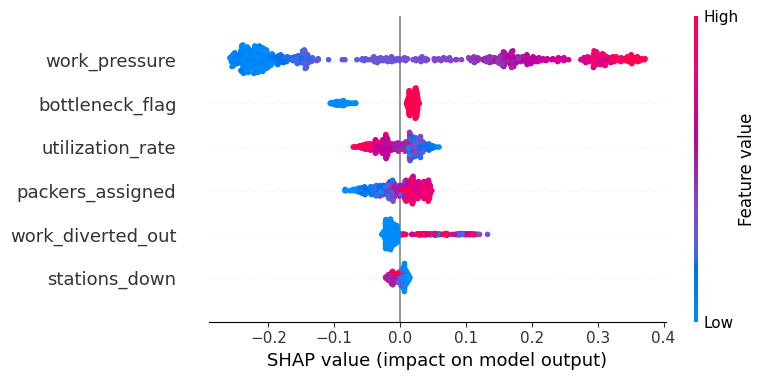

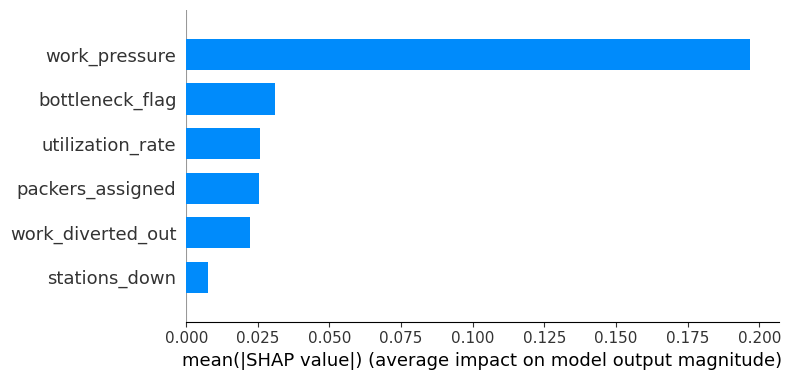

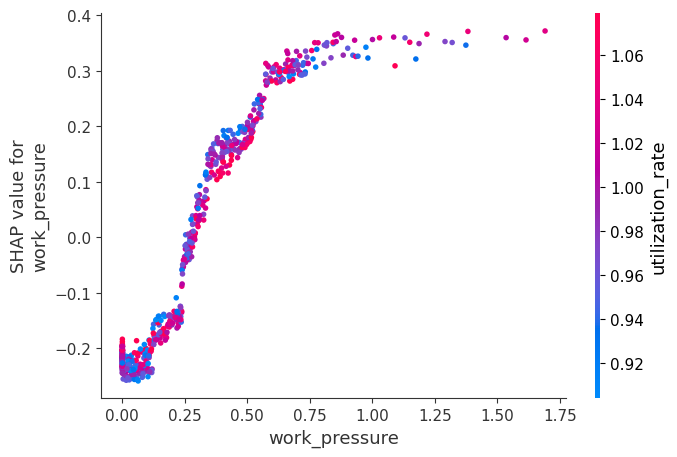

In [44]:
shap.summary_plot(
    shap_class_1,
    X_test
)

shap.summary_plot(
    shap_class_1,
    X_test,
    plot_type="bar"
)

shap.dependence_plot(
    "work_pressure",
    shap_class_1,
    X_test
)


*To further investigate the relationship between operational variables and next-hour backlog risk, SHAP dependence plots were generated. With work_pressure seeming to be the dominant feature associated with risk, the dependence plots displayed its contribution to work pressure, while color-coding other features according to their respective values.*

*The horizontal axis represents the actual value of work_pressure, and the vertical axis represents the SHAP value associated with it. Positive SHAP values indicate that work pressure increases the predicted probability of backlog risk, and negative SHAP values decrease the prediction. The color scale represents the value of a second operational variable, allowing potential interaction effects to be visually examined.*

*The dependence plots confirms the overall relationship between work pressure and backlog risk as it remained highly consistent: as work pressure increased, the SHAP contribution generally increased. This mirrors real-time operational risk, with higher workload pressure consistently pushing predictions toward elevated backlog risk.*

*This suggests that work_pressure acts is a strong operational indicator of backlog risk. Variables such as staffing levels, utilization rate, bottleneck conditions, station downtime, and work diversion may influence the operating environment, but they do not substantially alter the overall relationship between work pressure and backlog risk. It also supports earlier findings from sensitivity analysis, logistic regression, decision tree modeling, and Random Forest feature importance.*

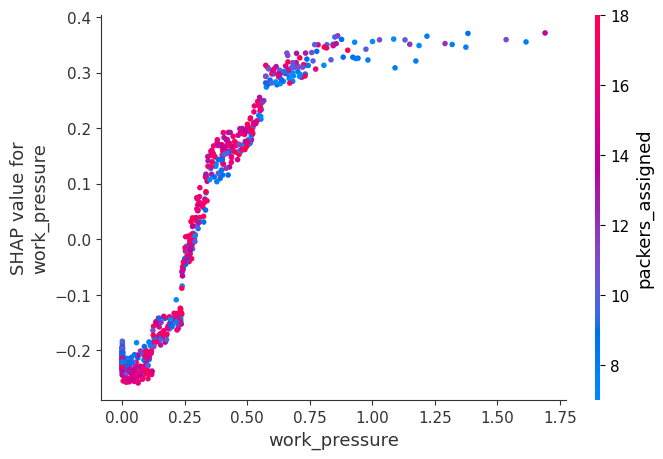

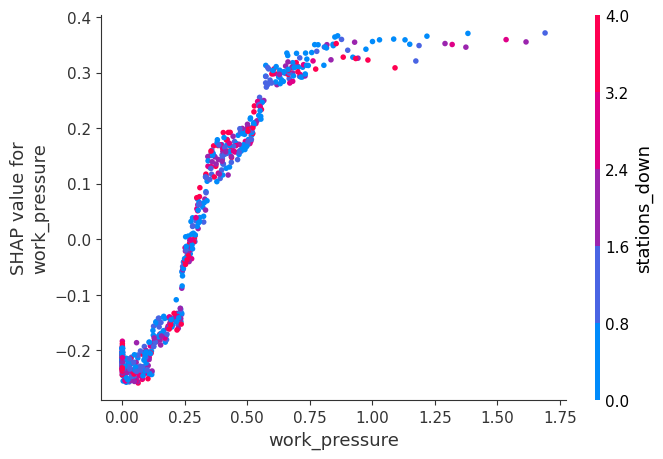

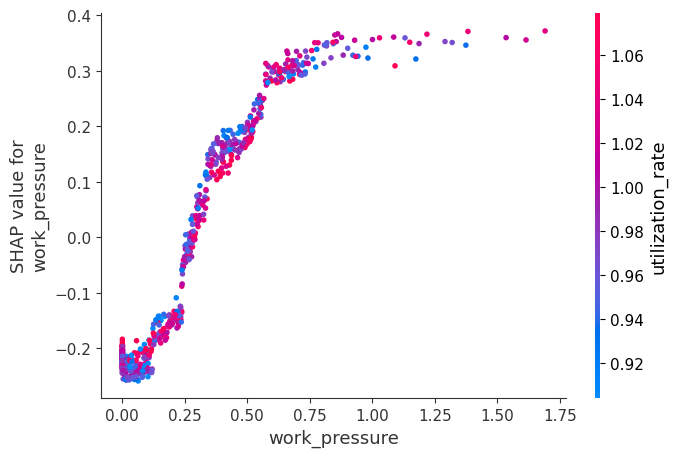

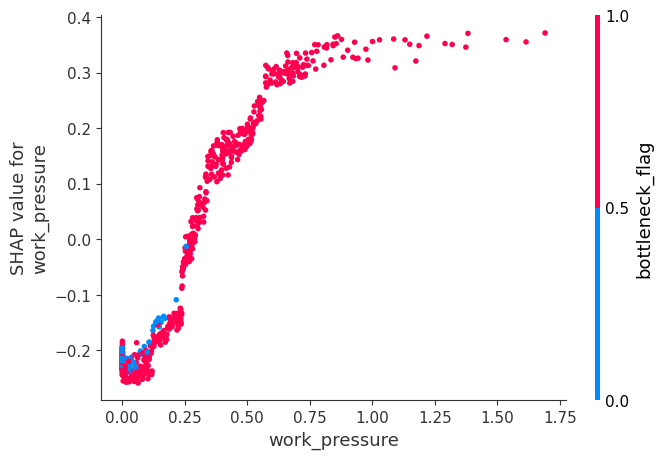

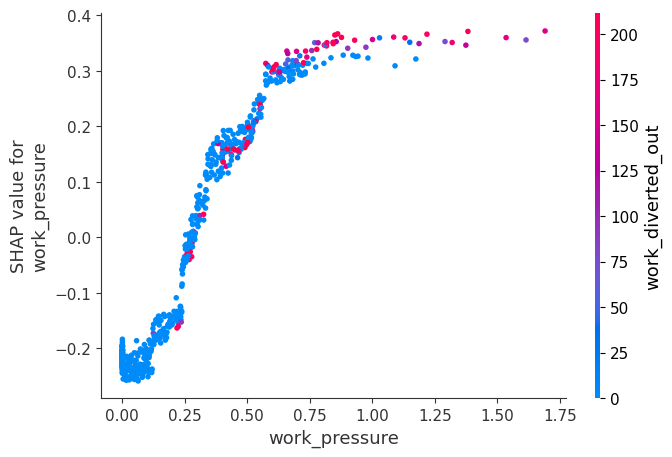

In [45]:
# Provide a color scale for each secondary feature with work_pressure as the primary driver
for feature in X_test.columns:
    if feature != "work_pressure":
      shap.dependence_plot(
        "work_pressure",
        shap_class_1,
        X_test,
        interaction_index=feature
    )

*Moderate-to-high utilization levels reduced predicted backlog risk by enabling available capacity to be converted into throughput, as shown in the dependence plot below. But at extremely high utilization levels, backlog risk increased again. This pattern likely reflects reduced operational flexibility instead of suggesting a single causal factor. When utilization is already near capacity limits, small disruptions, like station downtime, labor reassignment, or unexpected workload increases, can more readily reduce throughput below incoming demand. As a result, the system becomes increasingly vulnerable to backlog growth despite operating at high utilization levels.*

*Note that even at different work pressure levels, the plots still show the same shape. Work pressure increases (shown as purple and red dots) operating outside the optimal utilization range has increasingly severe consequences for backlog risk.*

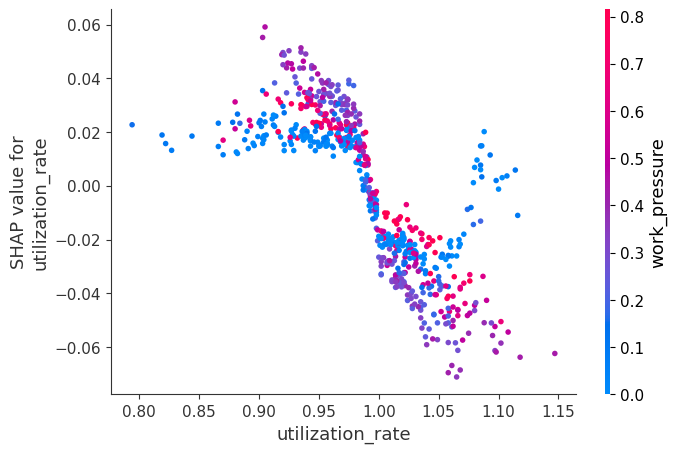

In [46]:
shap.dependence_plot(
    "utilization_rate",
    shap_class_1,
    X_test
)

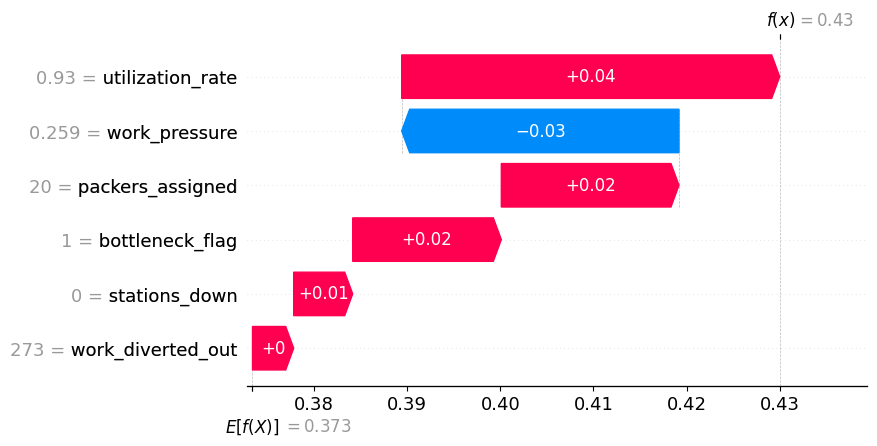


Explainer's expected value:  [0.62660579 0.37339421]
RF model's average predicted probability:  0.3657842680496502

Predicted probability from the RF mode:  0.42998614721173445
Predicated probability from the SHAP explainer:  0.429990914240188


In [47]:
# The following code grabs a random observation from the test set,
# starts from a base probability value, adds the SHAP values for each
# column to arrive at a final probability. The waterfall plot will
# show the contribution for each feature. This cell can be rerun as it
# will grab a new observation.

sample_idx = np.random.randint(0, len(X_test))

explanation = shap.Explanation(
    values=shap_class_1[sample_idx],
    base_values=base_value,
    data=X_test.iloc[sample_idx],
    feature_names=X_test.columns
)

shap.plots.waterfall(explanation)

print("\nExplainer's expected value: ",explainer.expected_value)
print("RF model's average predicted probability: ",rf_model.predict_proba(X_train)[:,1].mean())

# Verify how close the Random Forest model and the SHAP explainer
# are for the chosen observation.
pred_prob = rf_model.predict_proba(
    X_test.iloc[[sample_idx]]
)[0,1]

shap_prob = (
    base_value
    + shap_class_1[sample_idx].sum()
)

print("\nPredicted probability from the RF mode: ",pred_prob)
print("Predicated probability from the SHAP explainer: ",shap_prob)

*At the highest risk probability, SHAP still calculates work_pressure as the dominant factor. Despite Work_diverted_out appearing as the 2nd dominant feature, it does not drive backlog risk but instead is a response to risk, much like adding additional packers.*

Highest predicted risk probability: 0.8922396221411019
work_pressure          1.130789
packers_assigned      10.000000
stations_down          0.000000
utilization_rate       0.960000
bottleneck_flag        1.000000
work_diverted_out    190.000000
Name: 2026-04-11 01:00:00, dtype: float64


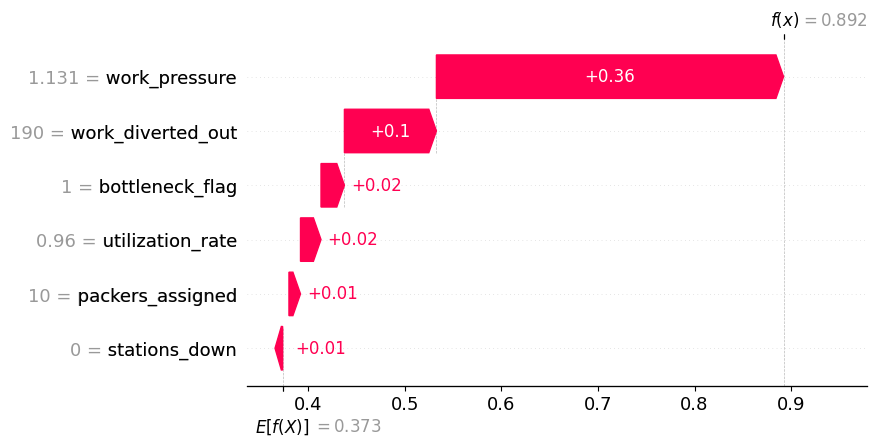

In [48]:
# Get the observation with the highest risk probability, and
# see how SHAP explains the contributions of each explanatory feature

risk_probs = rf_model.predict_proba(X_test)[:, 1]

high_risk_idx = np.argmax(risk_probs)

print("Highest predicted risk probability:", risk_probs[high_risk_idx])
print(X_test.iloc[high_risk_idx])

high_risk_explanation = shap.Explanation(
    values=shap_class_1[high_risk_idx],
    base_values=base_value,
    data=X_test.iloc[high_risk_idx],
    feature_names=X_test.columns
)

shap.plots.waterfall(high_risk_explanation)

*The final group of analyses will compare throughput and backlog over a 24-hour period, incrementally changing one exploratory feature's values and holding the remaining constant. The final results from each scenario run will be captured and compared, with measurements at -30% change, 0% change, and +30% change.*

*It is shown that work_stress is still the primary driver.*

In [49]:
print("Mean net incoming:", df["net_incoming_volume"].mean())
print("Mean line capacity:", df["line_capacity"].mean())
print("Mean backlog:", df["backlog_units"].mean())
print("Capacity minus incoming:",
      df["line_capacity"].mean() - df["net_incoming_volume"].mean())

Mean net incoming: 1109.5787401574803
Mean line capacity: 1125.4038906901344
Mean backlog: 355.7814960629921
Capacity minus incoming: 15.825150532654106


*Initial analyses proved the operations setup was stable, producing
no backlog. As nice as that is, it doesn't provide insight as to how
the system performs under great duress. A base backlog was introduced
that would generate "what-if" stress tests.*

In [50]:
base_backlog = np.random.randint(df["backlog_units"].mean().round(0) * 2,
                                 df["backlog_units"].mean().round(0) * 3
                                 ) + 1000

print(base_backlog)
# This will hold the results of every sensitivity analysis to compare against each other
comparison_results = []

1860


*This function calculates the final backlog and average throughput accumulated during a time series defined in hour-long slots. It takes in a structure with the minimum fields net_incoming_volume, work_diverted_out, and line_capacity, the starting backlog (if not provided then the average of the dataframe's backlog_units as defined above), and the number of time slots in hours. A sample call is as follows:

```
# A sample call, where "scenario" is a copy of the dataframe
# being analysed
backlog, avg_throughput = run_simulation(scenario)

# An alternative call, with starting backlog and number of hours
# included

backlog, avg_throughput = run_simulation(scenario, 1500, 12)
```


In [51]:
def run_simulation(
    scenario,
    starting_backlog = base_backlog,
    hours=24
):

    backlog = starting_backlog
    total_processed = 0

    # Despite what may be planned, incoming could be different
    # work_divered_out is usually a factor of demand and available capacity
    base_incoming = (
        scenario["net_incoming_volume"].mean()
        - scenario["work_diverted_out"].mean()
    )

    capacity = (
        scenario["line_capacity"].mean()
    )

    # hours is defaulted to 24 but can be overwritten upon call
    for t in range(hours):

        # Calculate available work for just one time slot
        available_work_t = (
            base_incoming + backlog
        )

        processed_t = min(
            available_work_t,
            capacity
        )

        backlog = max(
            0,
            available_work_t - processed_t
        )

        total_processed += processed_t

    avg_throughput = (
        total_processed / hours
    )

    return backlog, avg_throughput

*This function provides the backlog for changes to a feature at
the largest reduction, at no change, and the largest increase.
The goal is to show if changes to final backlog have different results
to changes of a single feature from full swings, or no change upon reaching a certain percent change.
It takes in a structure of backlog results with their lever names, types, response types, and observations.*

```
# A sensitivity dataframe is created from the results of the
# run_simuation function.

backlog, avg_throughput = run_simulation(scenario)
    results.append({
        "Staffing_Change_%": change * 100,
        "Final_Backlog": backlog,
        "Avg_Throughput": avg_throughput
    })

staffing_changes_sensitivity_df = pd.DataFrame(results)

# The following is a calling sample

staffing_summary = summarize_sensitivity(  
  staffing_changes_sensitivity_df,
  "Staffing_Change_%",
  "Staffing Change",
  "Direct Lever",
  "Threshold/Saturation",
  "Additional staffing reduced backlog until gains flattened"
)
```



In [52]:
def summarize_sensitivity(
    sensitivity_df,
    change_col,
    lever_name,
    lever_type,
    response_type=None,
    observation=None
):

    backlog_neg30 = (
        sensitivity_df.loc[
            sensitivity_df[change_col].idxmin(),
            "Final_Backlog"
        ]
    )

    backlog_zero = (
        sensitivity_df.loc[
            sensitivity_df[change_col]
            .abs()
            .idxmin(),
            "Final_Backlog"
        ]
    )

    backlog_pos30 = (
        sensitivity_df.loc[
            sensitivity_df[change_col].idxmax(),
            "Final_Backlog"
        ]
    )

    absolute_change = (
        backlog_pos30 - backlog_neg30
    )

    percent_change = (
        absolute_change / backlog_neg30
    ) * 100

    return {
      "Lever": lever_name,
      "Lever_Type": lever_type,
      "Backlog @ -30%": round(backlog_neg30),
      "Backlog @ 0%": round(backlog_zero),
      "Backlog @ +30%": round(backlog_pos30),
      "Absolute_Change": round(absolute_change),
      "Percent_Change": round(percent_change, 1),
      "Response_Type": response_type,
      "Observation": observation
    }


## Stress-Test Scenario Design

*After correcting the incoming workload definition to use actual net incoming volume, the baseline system had enough capacity to clear backlog under most scenarios. While this is operationally reasonable, it provided limited insight for sensitivity analysis because most levers produced little visible difference once backlog reached zero.*

*To evaluate how the system behaves under more constrained conditions, a stress-test scenario was introduced by increasing the starting backlog above normal baseline levels. This creates a more challenging operating environment and allows the analysis to compare how different operational levers affect backlog recovery when the system is already under pressure.*

*This scenario should be interpreted as a resilience test rather than a typical operating baseline. The goal is not to claim that this backlog level is normal, but to examine which levers are most effective when backlog has already accumulated and management needs to stabilize or recover the operation.*

In [53]:
staffing_changes = np.arange(-0.30, 0.35, 0.05)

results = []

for change in staffing_changes:

    scenario = df.copy()

    # Modify staffing
    scenario["packers_assigned"] *= (
        1 + change
    )

    # Keep staffing realistic
    scenario["packers_assigned"] = (
        scenario["packers_assigned"]
        .clip(
            lower=0,
            upper=scenario["active_stations"]
        )
    )

    # Recalculate capacity
    scenario["line_capacity"] = (
        scenario["packers_assigned"]
        * scenario["avg_units_per_packer"]
    )

    # Run standardized simulation
    backlog, avg_throughput = run_simulation(scenario)

    results.append({
        "Staffing_Change_%": change * 100,
        "Final_Backlog": backlog,
        "Avg_Throughput": avg_throughput
    })

staffing_changes_sensitivity_df = pd.DataFrame(results)

staffing_summary = summarize_sensitivity(
    staffing_changes_sensitivity_df,
    "Staffing_Change_%",
    "Staffing Change",
    "Direct Lever",
    "Threshold/Saturation",
    "Additional staffing reduced backlog until gains flattened"
)

comparison_results.append(staffing_summary)

staffing_summary_df = (
    pd.DataFrame([staffing_summary])
    .round(2)
)

print(
    staffing_summary_df.to_string(index=False)
)

          Lever   Lever_Type  Backlog @ -30%  Backlog @ 0%  Backlog @ +30%  Absolute_Change  Percent_Change        Response_Type                                               Observation
Staffing Change Direct Lever            8914           812               0            -8914          -100.0 Threshold/Saturation Additional staffing reduced backlog until gains flattened


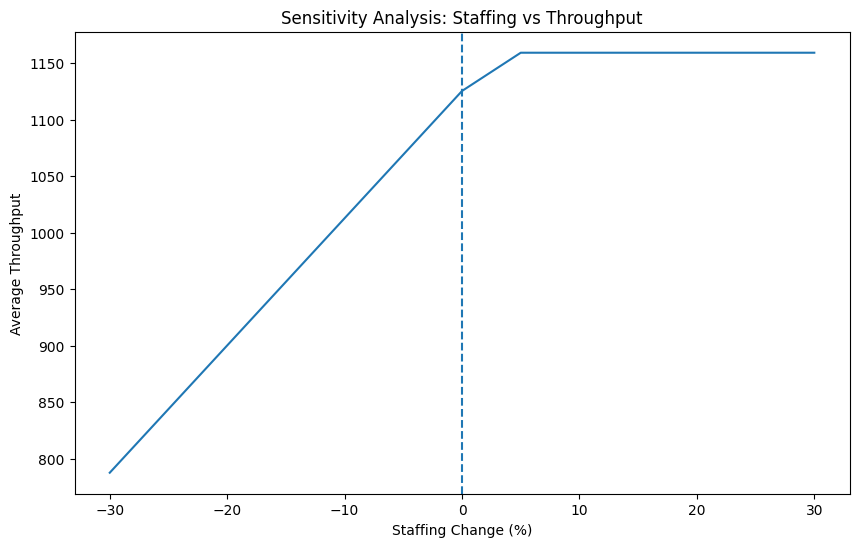

In [54]:
plt.figure(figsize=(10,6))

plt.plot(
    staffing_changes_sensitivity_df["Staffing_Change_%"],
    staffing_changes_sensitivity_df["Avg_Throughput"]
)

plt.axvline(
    x=0,
    linestyle="--"
)

plt.xlabel(
    "Staffing Change (%)"
)

plt.ylabel(
    "Average Throughput"
)

plt.title(
    "Sensitivity Analysis: Staffing vs Throughput"
)

plt.show()

In [55]:
work_diverted_changes = np.arange(-0.30, 0.35, 0.05)

results = []

for change in work_diverted_changes:

    scenario = df.copy()

    # Modify how much work is diverted
    scenario["work_diverted_out"] *= (
        1 + change
    )

    # Prevent negative diverted work
    scenario["work_diverted_out"] = (
        scenario["work_diverted_out"]
        .clip(lower=0)
    )

    # Recompute available work
    scenario["available_work"] = (
        + base_backlog
        + scenario["net_incoming_volume"]
        - scenario["work_diverted_out"]
    )

    # Run standardized simulation
    backlog, avg_throughput = run_simulation(scenario)

    results.append({
        "Work_Diverted_Change_%": change * 100,
        "Final_Backlog": backlog,
        "Avg_Throughput": avg_throughput
    })

work_diverted_changes_sensitivity_df = pd.DataFrame(
    results
)

work_diverted_summary = summarize_sensitivity(
    work_diverted_changes_sensitivity_df,
    "Work_Diverted_Change_%",
    "Work Diverted Change",
    "Direct Lever",
    "Weak Linear",
    "Diverting work reduced backlog consistently but with relatively small operational impact"
)

comparison_results.append(work_diverted_summary)

work_diverted_summary_df = pd.DataFrame(
    [work_diverted_summary]
).round(2)

print(work_diverted_summary_df.to_string(index=False))

               Lever   Lever_Type  Backlog @ -30%  Backlog @ 0%  Backlog @ +30%  Absolute_Change  Percent_Change Response_Type                                                                              Observation
Work Diverted Change Direct Lever            1012           812             611             -401           -39.6   Weak Linear Diverting work reduced backlog consistently but with relatively small operational impact


In [56]:
avg_units_packed_changes = np.arange(-0.30, 0.35, 0.05)

results = []

for change in avg_units_packed_changes:

    scenario = df.copy()

    # Modify productivity per packer
    scenario["avg_units_per_packer"] *= (1 + change)

    # Prevent negative units packed
    scenario["avg_units_per_packer"] = (
        scenario["avg_units_per_packer"]
        .clip(lower=0)
    )

    # Recalculate capacity
    scenario["line_capacity"] = (
        scenario["packers_assigned"]
        * scenario["avg_units_per_packer"]
    )

    # Run standardized simulation
    backlog, avg_throughput = run_simulation(
        scenario,
        scenario["backlog_units"].mean().round(0)
    )

    results.append({
        "Ave_Units_per_Packer_Change_%": change * 100,
        "Final_Backlog": backlog,
        "Avg_Throughput": avg_throughput
    })

avg_units_sensitivity_df = pd.DataFrame(
    results
)

avg_units_summary = summarize_sensitivity(
    avg_units_sensitivity_df,
    "Ave_Units_per_Packer_Change_%",
    "Average Units Per Packer Change",
    "Direct Lever",
    "Diminishing Returns",
    "Productivity improvements reduced backlog, though incremental gains weakened productivity at higher productivity levels"
)

comparison_results.append(avg_units_summary)

avg_units_summary_df = pd.DataFrame(
    [avg_units_summary]
).round(2)

print(avg_units_summary_df.to_string(index=False))

                          Lever   Lever_Type  Backlog @ -30%  Backlog @ 0%  Backlog @ +30%  Absolute_Change  Percent_Change       Response_Type                                                                                                             Observation
Average Units Per Packer Change Direct Lever            7410             0               0            -7410          -100.0 Diminishing Returns Productivity improvements reduced backlog, though incremental gains weakened productivity at higher productivity levels


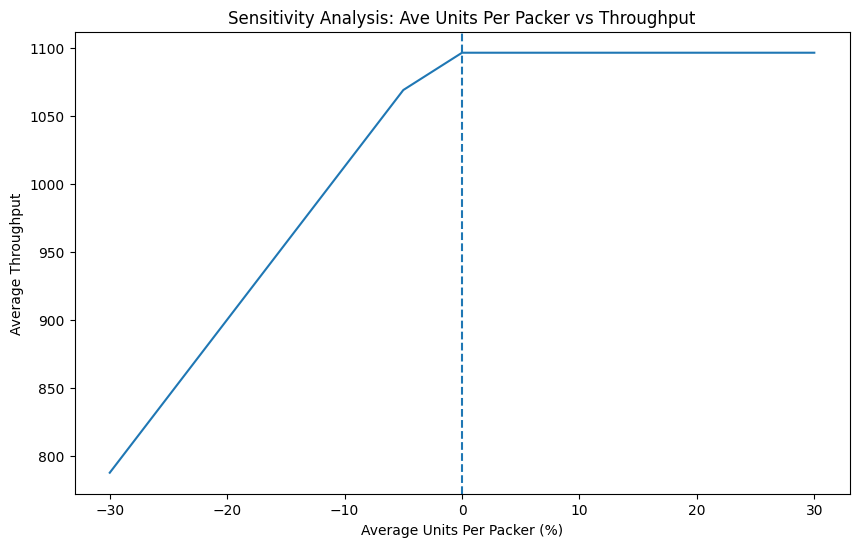

In [57]:
plt.figure(figsize=(10,6))

plt.plot(
    avg_units_sensitivity_df["Ave_Units_per_Packer_Change_%"],
    avg_units_sensitivity_df["Avg_Throughput"]
)

plt.axvline(
    x=0,
    linestyle="--"
)

plt.xlabel(
    "Average Units Per Packer (%)"
)

plt.ylabel(
    "Average Throughput"
)

plt.title(
    "Sensitivity Analysis: Ave Units Per Packer vs Throughput"
)

plt.show()

In [58]:
backlog_changes = np.arange(-0.30, 0.35, 0.05)

results = []

for change in backlog_changes:

    scenario = df.copy()

    # Modify starting backlog
    starting_backlog = (
        base_backlog * (1+change)
    )

    # Recompute available work
    scenario["available_work"] = (
        + scenario["backlog_units"]
        + scenario["net_incoming_volume"]
        - scenario["work_diverted_out"]
    )

    # Run standardized simulation
    backlog, avg_throughput = run_simulation(
        scenario,
        starting_backlog
    )

    results.append({
        "Starting_Backlog_Change_%": change * 100,
        "Final_Backlog": backlog,
        "Avg_Throughput": avg_throughput
    })

backlog_sensitivity_df = pd.DataFrame(
    results
)

backlog_summary = summarize_sensitivity(
    backlog_sensitivity_df,
    "Starting_Backlog_Change_%",
    "Starting Backlog Change",
    "Initial Condition",
    "Linear Persistence",
    "Existing congestion carried forward proportionally under fixed workload and capacity conditions"
)

comparison_results.append(backlog_summary)

backlog_summary_df = pd.DataFrame(
    [backlog_summary]
).round(2)

print(backlog_summary_df.to_string(index=False))

                  Lever        Lever_Type  Backlog @ -30%  Backlog @ 0%  Backlog @ +30%  Absolute_Change  Percent_Change      Response_Type                                                                                     Observation
Starting Backlog Change Initial Condition             254           812            1370             1116           440.2 Linear Persistence Existing congestion carried forward proportionally under fixed workload and capacity conditions


In [59]:
line_capacity_changes = np.arange(-0.30, 0.35, 0.05)

results = []

for change in line_capacity_changes:

    scenario = df.copy()

    # Modify line capacity
    scenario["line_capacity"] *= (1 + change)

    # Don't allow 0 or negative capacity
    scenario["line_capacity"] = (
        scenario["line_capacity"]
        .clip(lower=1)
    )

    # Run standardized simulation
    backlog, avg_throughput = run_simulation(scenario)

    results.append({
        "Line_Capacity_Change_%": change * 100,
        "Final_Backlog": backlog,
        "Avg_Throughput": avg_throughput
    })

line_capacity_sensitivity_df = pd.DataFrame(
    results
)

line_capacity_summary = summarize_sensitivity(
    line_capacity_sensitivity_df,
    "Line_Capacity_Change_%",
    "Line Capacity Change",
    "Saturation",
    "Saturation / Capacity Expansion",
    "Increasing total line capacity reduced backlog until throughput approached operational equilibrium"
)

comparison_results.append(line_capacity_summary)

line_capacity_summary_df = pd.DataFrame(
    [line_capacity_summary]
).round(2)

print(line_capacity_summary_df.to_string(index=False))

               Lever Lever_Type  Backlog @ -30%  Backlog @ 0%  Backlog @ +30%  Absolute_Change  Percent_Change                   Response_Type                                                                                        Observation
Line Capacity Change Saturation            8914           812               0            -8914          -100.0 Saturation / Capacity Expansion Increasing total line capacity reduced backlog until throughput approached operational equilibrium


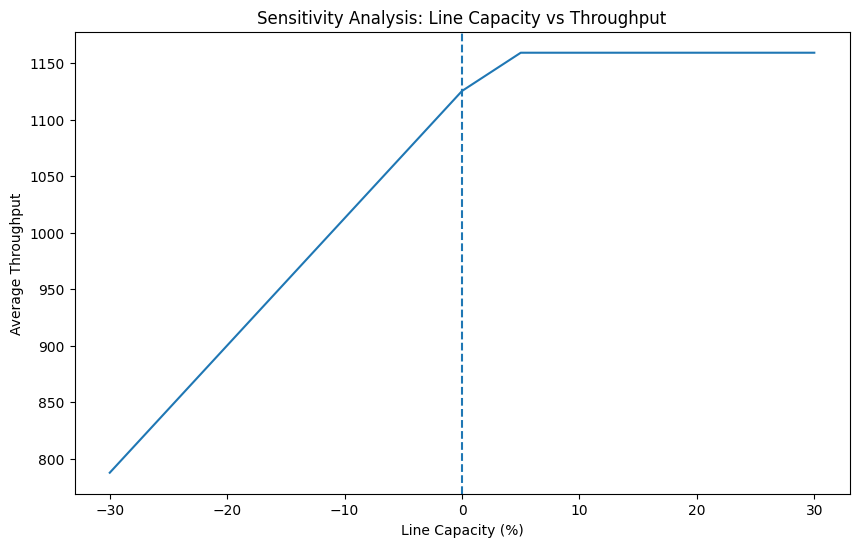

In [60]:
plt.figure(figsize=(10,6))

plt.plot(
    line_capacity_sensitivity_df["Line_Capacity_Change_%"],
    line_capacity_sensitivity_df["Avg_Throughput"]
)

plt.axvline(
    x=0,
    linestyle="--"
)

plt.xlabel(
    "Line Capacity (%)"
)

plt.ylabel(
    "Average Throughput"
)

plt.title(
    "Sensitivity Analysis: Line Capacity vs Throughput"
)

plt.show()

In [61]:
stations_down_changes = np.arange(-0.30, 0.35, 0.05)

results = []

for change in stations_down_changes:

    scenario = df.copy()

    # Modify line capacity
    scenario["stations_down"] *= (1 + change)

    # Don't allow more stations down than available stations
    scenario["stations_down"] = (
        scenario["stations_down"]
        .clip(lower = 0, upper = scenario['total_stations'])
    )

    # Update active stations
    scenario["active_stations"] = (
        scenario["total_stations"]
        - scenario["stations_down"]
    )

    # Ensure staffing cannot exceed active stations
    scenario["packers_assigned"] = (
        scenario["packers_assigned"]
        .clip(lower = 0, upper = scenario["active_stations"])
    )

    # Capacity based on actual staffed stations
    scenario["line_capacity"] = (
        scenario["packers_assigned"]
        * scenario["avg_units_per_packer"]
    )

    # Run standardized simulation
    backlog, avg_throughput = run_simulation(scenario)

    results.append({
        "Stations_Down_Change_%": change * 100,
        "Final_Backlog": backlog,
        "Avg_Throughput": avg_throughput
    })

stations_down_sensitivity_df = pd.DataFrame(results)

stations_down_summary = summarize_sensitivity(
    stations_down_sensitivity_df,
    "Stations_Down_Change_%",
    "Stations Down Change",
    "Constraint",
    "Piecewise / Constraint Threshold",
    "Reduced station availability had limited effect until active stations began constraining assignable staffing"
)

comparison_results.append(stations_down_summary)

stations_down_summary_df = pd.DataFrame(
    [stations_down_summary]
).round(2)

print(stations_down_summary_df.to_string(index=False))

               Lever Lever_Type  Backlog @ -30%  Backlog @ 0%  Backlog @ +30%  Absolute_Change  Percent_Change                    Response_Type                                                                                                  Observation
Stations Down Change Constraint             812           812            1010              199            24.5 Piecewise / Constraint Threshold Reduced station availability had limited effect until active stations began constraining assignable staffing


In [62]:
comparison_df = pd.DataFrame(
    comparison_results).round({
        "Backlog @ -30%": 0,
        "Backlog @ 0%": 0,
        "Backlog @ +30%": 0,
        "Absolute_Change": 0,
        "Percent_Change": 2
    })

comparison_df = (
    comparison_df
    .sort_values(
        by="Percent_Change",
        ascending=False
    )
)

comparison_df

,Lever,Lever_Type,Backlog @ -30%,Backlog @ 0%,Backlog @ +30%,Absolute_Change,Percent_Change,Response_Type,Observation
3,Starting Backlog Change,Initial Condition,254,812,1370,1116,440.2,Linear Persistence,Existing congestion carried forward proportion...
5,Stations Down Change,Constraint,812,812,1010,199,24.5,Piecewise / Constraint Threshold,Reduced station availability had limited effec...
1,Work Diverted Change,Direct Lever,1012,812,611,-401,-39.6,Weak Linear,Diverting work reduced backlog consistently bu...
0,Staffing Change,Direct Lever,8914,812,0,-8914,-100.0,Threshold/Saturation,Additional staffing reduced backlog until gain...
2,Average Units Per Packer Change,Direct Lever,7410,0,0,-7410,-100.0,Diminishing Returns,"Productivity improvements reduced backlog, tho..."
4,Line Capacity Change,Saturation,8914,812,0,-8914,-100.0,Saturation / Capacity Expansion,Increasing total line capacity reduced backlog...


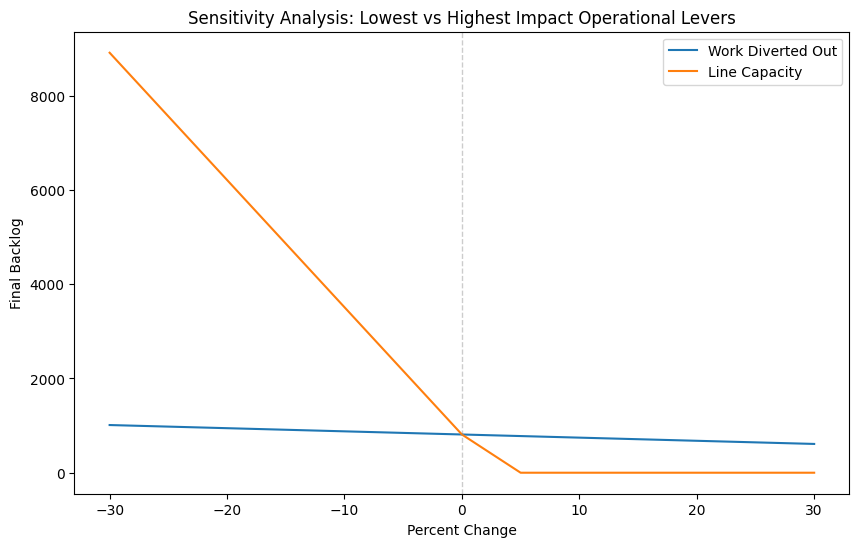

In [63]:
plt.figure(figsize=(10,6))

plt.plot(
    work_diverted_changes_sensitivity_df["Work_Diverted_Change_%"],
    work_diverted_changes_sensitivity_df["Final_Backlog"],
    label="Work Diverted Out"
)

plt.plot(
    line_capacity_sensitivity_df["Line_Capacity_Change_%"],
    line_capacity_sensitivity_df["Final_Backlog"],
    label="Line Capacity"
)

plt.axvline(
    x=0,
    linestyle="--",
    linewidth=1,
    alpha=0.4,
    color="gray"
)

plt.xlabel("Percent Change")
plt.ylabel("Final Backlog")
plt.title(
    "Sensitivity Analysis: Lowest vs Highest Impact Operational Levers"
)

plt.legend()

plt.show()

*The following concludes the analysis efforts by determining the ceiling when backlog will start accumulating. Note that previous versions of the code were written and run to achieve the treshold value as precise as possible.*

In [64]:
# Set up a holding area
scenario_results = []

stress_levels = np.arange(0.9,1.5,0.005)

for stress in stress_levels:

    backlog = 0

    for t in range(24):

        incoming = (
            df["net_incoming_volume"].mean()
            * stress
        )

        capacity = (
            df["line_capacity"].mean()
        )

        available_work = (
            incoming
            + backlog
        )

        processed = min(
            available_work,
            capacity
        )

        backlog = max(
            0,
            available_work - processed
        )

    scenario_results.append({
        "Stress_Level":stress,
        "Final_Backlog":backlog
    })

scenario_df = pd.DataFrame(
    scenario_results
)


In [69]:
# Find first point where backlog begins accumulating

ceiling_idx = scenario_df[
    scenario_df["Final_Backlog"] > 0
].index[0]

ceiling = scenario_df.loc[
    ceiling_idx,
    "Stress_Level"
]

print(f"Throughput ceiling assuming a static-capacity operation: {ceiling:.4f}")

Throughput ceiling assuming a static-capacity operation: 1.0150


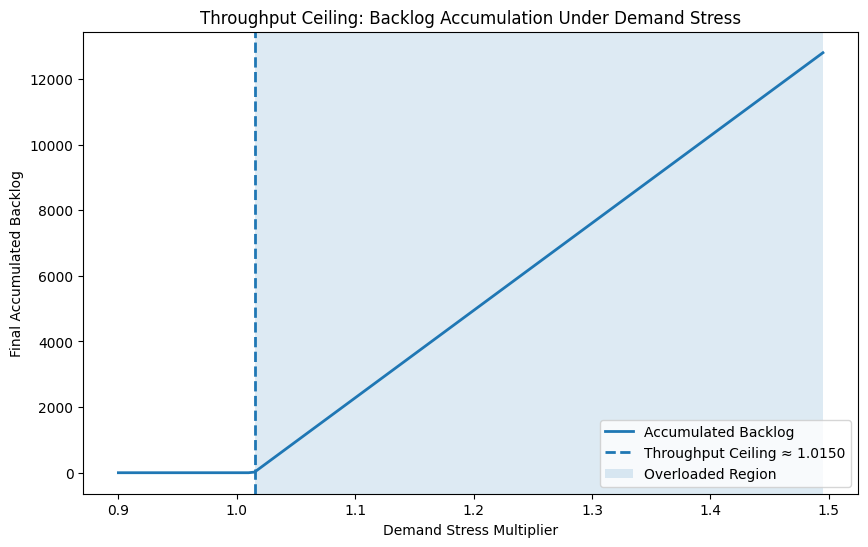

In [66]:
# Find first stress level where backlog starts accumulating

plt.figure(figsize=(10, 6))

plt.plot(
    scenario_df["Stress_Level"],
    scenario_df["Final_Backlog"],
    linewidth=2,
    label="Accumulated Backlog"
)

# Throughput ceiling marker
plt.axvline(
    x=ceiling,
    linestyle="--",
    linewidth=2,
    label=f"Throughput Ceiling ≈ {ceiling:.4f}"
)

# Shade overloaded region
plt.axvspan(
    ceiling,
    scenario_df["Stress_Level"].max(),
    alpha=0.15,
    label="Overloaded Region"
)

plt.xlabel("Demand Stress Multiplier")
plt.ylabel("Final Accumulated Backlog")
plt.title("Throughput Ceiling: Backlog Accumulation Under Demand Stress")
plt.legend()
plt.show()

